In [150]:
from datetime import datetime, timedelta
from finpie.datasource.service import DataService
from mt5_backtest_runner import run_mt5_backtest
import glob
import os
import pandas as pd
from functools import reduce

In [151]:
path = r"C:\Users\enzob\AppData\Roaming\MetaQuotes\Terminal\D0E8209F77C8CF37AD8BF550E51FF075\MQL5\Profiles\Tester\algo\prod_v1\\"
data_path = r"C:\Users\enzob\AppData\Roaming\MetaQuotes\Terminal\Common\Files\backtests\\"
strategies = {
    'single': 'lamalgo\\strategy\\single\\PricesStrategy',
    'pair': 'lamalgo\\strategy\\pair\\PricesPairStrategy'
}

In [155]:
# Get all .set files in the path
set_files = glob.glob(os.path.join(path, "*.set"))

files = []
if set_files:
    for file in set_files:
        files.append(os.path.basename(file))

In [156]:
backtest_map = {}
current_file = None

for file in files:
    strategy_key = 'single' if file.startswith('single') else 'pair'
    run_mt5_backtest(
    expert_name=strategies[strategy_key], 
    expert_params_file=f"algo\\prod_v1\\{file}",  # Arquivo .set com seus parâmetros
    symbol="WIN$N", 
    start_date="2020.01.01",
    end_date="2025.12.31",
    timeframe="M1",
    model = 2)
    try:
        # Get the latest file in data_path
        current_file_new = max(glob.glob(os.path.join(data_path, "*")), key=os.path.getctime)
        if current_file_new != current_file:
            current_file = current_file_new
            strategy_name = file.replace('.set', '')
            df = pd.read_csv(current_file_new, sep='\t', decimal=',', encoding='UTF-16LE')
            df[strategy_name] = df['PnL'].astype(float)
            backtest_map[strategy_name] = df[['Date', strategy_name]]
        else:
            raise Exception(f"File {file} did not change")
    except Exception as e:
        print(f"Error processing file {file}: {e}")

Error processing file single_20_26_15_15_15_500_200_1_0_1.set: max() iterable argument is empty


In [157]:
merged_df = reduce(lambda left, right: pd.merge(left, right, on='Date', how='outer'), backtest_map.values())
merged_df.fillna(0, inplace=True)
#merged_df['total'] = merged_df[merged_df.columns[1:]].sum(axis=1)
merged_df['Date'] = pd.to_datetime(merged_df['Date'])
merged_df = merged_df.groupby('Date').last()

In [158]:
merged_df

,single_20_26_15_15_15_500_200_1_0_4,single_60_28_3_3_4_920_420_1_0_1,single_60_28_3_3_4_920_420_1_0_4,single_65_24_1_1_1_333_153_1_0_1,single_65_24_1_1_1_333_153_1_0_4,single_65_26_2_2_2_600_293_1_0_1,single_65_26_2_2_2_600_293_1_0_4,single_65_26_2_2_3_586_293_1_0_1,single_65_26_2_2_3_586_293_1_0_4,single_65_26_2_2_3_653_293_1_0_1,single_65_26_2_2_3_653_293_1_0_4,single_65_26_2_2_3_666_293_1_0_1,single_65_26_2_2_3_666_293_1_0_4,single_65_26_2_2_3_666_306_1_0_1,single_65_26_2_2_3_666_306_1_0_4
Date,,,,,,,,,,,,,,,
2020-06-19,0.0,420.0,447.0,153.0,149.0,293.0,298.0,293.0,298.0,293.0,298.0,293.0,298.0,306.0,298.0
2020-06-22,420.0,420.0,468.0,152.0,142.0,293.0,262.0,293.0,262.0,293.0,262.0,293.0,262.0,304.0,284.0
2020-06-23,90.0,-768.0,387.0,-203.0,0.0,-600.0,-594.0,-586.0,-594.0,-512.0,0.0,-512.0,0.0,-512.0,0.0
2020-06-24,0.0,420.0,0.0,153.0,-273.0,293.0,282.0,293.0,282.0,293.0,-578.0,293.0,-578.0,306.0,-578.0
2020-06-25,105.0,-920.0,-903.0,153.0,155.0,-600.0,-602.0,-586.0,-588.0,-653.0,-674.0,-666.0,-674.0,-666.0,-674.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-11,135.0,420.0,327.0,153.0,176.0,293.0,300.0,293.0,300.0,293.0,300.0,293.0,300.0,306.0,300.0
2025-06-12,0.0,420.0,408.0,153.0,156.0,293.0,298.0,293.0,298.0,293.0,298.0,293.0,298.0,306.0,312.0
2025-06-13,0.0,-291.0,0.0,-14.0,0.0,-40.0,0.0,-40.0,0.0,-40.0,0.0,-40.0,0.0,-40.0,0.0


In [159]:
df = merged_df.cumsum().dropna()

In [160]:
df['cdi'] = 100_000 * ((1.07 ** (1/252)) - 1)
df['cdi'] = df['cdi'].cumsum()

In [161]:
df

,single_20_26_15_15_15_500_200_1_0_4,single_60_28_3_3_4_920_420_1_0_1,single_60_28_3_3_4_920_420_1_0_4,single_65_24_1_1_1_333_153_1_0_1,single_65_24_1_1_1_333_153_1_0_4,single_65_26_2_2_2_600_293_1_0_1,single_65_26_2_2_2_600_293_1_0_4,single_65_26_2_2_3_586_293_1_0_1,single_65_26_2_2_3_586_293_1_0_4,single_65_26_2_2_3_653_293_1_0_1,single_65_26_2_2_3_653_293_1_0_4,single_65_26_2_2_3_666_293_1_0_1,single_65_26_2_2_3_666_293_1_0_4,single_65_26_2_2_3_666_306_1_0_1,single_65_26_2_2_3_666_306_1_0_4,cdi
Date,,,,,,,,,,,,,,,,
2020-06-19,0.0,420.0,447.0,153.0,149.0,293.0,298.0,293.0,298.0,293.0,298.0,293.0,298.0,306.0,298.0,26.852275
2020-06-22,420.0,840.0,915.0,305.0,291.0,586.0,560.0,586.0,560.0,586.0,560.0,586.0,560.0,610.0,582.0,53.704549
2020-06-23,510.0,72.0,1302.0,102.0,291.0,-14.0,-34.0,0.0,-34.0,74.0,560.0,74.0,560.0,98.0,582.0,80.556824
2020-06-24,510.0,492.0,1302.0,255.0,18.0,279.0,248.0,293.0,248.0,367.0,-18.0,367.0,-18.0,404.0,4.0,107.409098
2020-06-25,615.0,-428.0,399.0,408.0,173.0,-321.0,-354.0,-293.0,-340.0,-286.0,-692.0,-299.0,-692.0,-262.0,-670.0,134.261373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-11,36360.0,36233.0,65805.0,16549.0,23944.0,31134.0,48080.0,31872.0,48772.0,29901.0,51292.0,29973.0,53268.0,30814.0,54642.0,33243.115964
2025-06-12,36360.0,36653.0,66213.0,16702.0,24100.0,31427.0,48378.0,32165.0,49070.0,30194.0,51590.0,30266.0,53566.0,31120.0,54954.0,33269.968238
2025-06-13,36360.0,36362.0,66213.0,16688.0,24100.0,31387.0,48378.0,32125.0,49070.0,30154.0,51590.0,30226.0,53566.0,31080.0,54954.0,33296.820513


In [162]:
from finpie.data.timeseries import TimeSeries
from finpie.data.multitimeseries import MultiTimeSeries
from finpie.data.spreadtimeseries import SpreadTimeSeries
from finpie.data.ratiotimeseries import RatioTimeSeries
import numpy as np

In [163]:
mts = MultiTimeSeries(df)

In [164]:
mts.correlation()

,single_20_26_15_15_15_500_200_1_0_4,single_60_28_3_3_4_920_420_1_0_1,single_60_28_3_3_4_920_420_1_0_4,single_65_24_1_1_1_333_153_1_0_1,single_65_24_1_1_1_333_153_1_0_4,single_65_26_2_2_2_600_293_1_0_1,single_65_26_2_2_2_600_293_1_0_4,single_65_26_2_2_3_586_293_1_0_1,single_65_26_2_2_3_586_293_1_0_4,single_65_26_2_2_3_653_293_1_0_1,single_65_26_2_2_3_653_293_1_0_4,single_65_26_2_2_3_666_293_1_0_1,single_65_26_2_2_3_666_293_1_0_4,single_65_26_2_2_3_666_306_1_0_1,single_65_26_2_2_3_666_306_1_0_4,cdi
single_20_26_15_15_15_500_200_1_0_4,1.000000,0.018663,0.065174,-0.092674,-0.015131,0.009216,-0.039037,0.004596,-0.033575,0.025405,-0.023876,0.031372,0.012552,0.167877,-0.028841,-0.101577
single_60_28_3_3_4_920_420_1_0_1,0.018663,1.000000,0.013447,0.126175,0.028061,-0.035562,0.609459,-0.997506,0.662008,0.915670,0.022375,-0.942068,-0.012841,0.620600,0.016565,0.140130
single_60_28_3_3_4_920_420_1_0_4,0.065174,0.013447,1.000000,0.085139,-0.174508,0.004262,0.003588,0.009856,-0.014222,0.042161,-0.223575,0.054112,-0.182641,0.262794,0.237563,0.365708
single_65_24_1_1_1_333_153_1_0_1,-0.092674,0.126175,0.085139,1.000000,0.271768,-0.133584,-0.279559,-0.114273,-0.248739,0.156582,0.241018,-0.007740,0.151865,0.297683,-0.211165,0.436355
single_65_24_1_1_1_333_153_1_0_4,-0.015131,0.028061,-0.174508,0.271768,1.000000,0.028006,-0.066182,-0.054657,-0.051818,-0.009099,0.964061,-0.102043,0.885236,-0.166403,-0.960712,0.278365
single_65_26_2_2_2_600_293_1_0_1,0.009216,-0.035562,0.004262,-0.133584,0.028006,1.000000,0.029148,0.061710,0.023826,-0.387259,-0.007260,-0.132875,-0.004219,-0.378193,0.008118,0.029520
single_65_26_2_2_2_600_293_1_0_4,-0.039037,0.609459,0.003588,-0.279559,-0.066182,0.029148,1.000000,-0.880840,0.997162,0.537201,-0.129908,-0.660079,-0.171238,0.192939,0.212262,-0.131370
single_65_26_2_2_3_586_293_1_0_1,0.004596,-0.997506,0.009856,-0.114273,-0.054657,0.061710,-0.880840,1.000000,-0.899528,-0.918336,-0.046318,0.958412,-0.004959,-0.617756,0.005966,-0.130576
single_65_26_2_2_3_586_293_1_0_4,-0.033575,0.662008,-0.014222,-0.248739,-0.051818,0.023826,0.997162,-0.899528,1.000000,0.585229,-0.113322,-0.706500,-0.153732,0.227704,0.193552,-0.113118
single_65_26_2_2_3_653_293_1_0_1,0.025405,0.915670,0.042161,0.156582,-0.009099,-0.387259,0.537201,-0.918336,0.585229,1.000000,0.000790,-0.760361,-0.028848,0.782143,0.032185,0.113194


In [165]:
mts.max_drawdown(percentage=False)

single_20_26_15_15_15_500_200_1_0_4    -4950.0
single_60_28_3_3_4_920_420_1_0_1      -11225.0
single_60_28_3_3_4_920_420_1_0_4       -5241.0
single_65_24_1_1_1_333_153_1_0_1       -2830.0
single_65_24_1_1_1_333_153_1_0_4       -3431.0
single_65_26_2_2_2_600_293_1_0_1       -4925.0
single_65_26_2_2_2_600_293_1_0_4       -4924.0
single_65_26_2_2_3_586_293_1_0_1       -4785.0
single_65_26_2_2_3_586_293_1_0_4       -4762.0
single_65_26_2_2_3_653_293_1_0_1       -4647.0
single_65_26_2_2_3_653_293_1_0_4       -4848.0
single_65_26_2_2_3_666_293_1_0_1       -4790.0
single_65_26_2_2_3_666_293_1_0_4       -4950.0
single_65_26_2_2_3_666_306_1_0_1       -4608.0
single_65_26_2_2_3_666_306_1_0_4       -4742.0
cdi                                        0.0
dtype: float64

In [166]:
equal_weights = {}
for col in mts.data.columns:
    equal_weights[col] = 1

In [167]:
equal_weights

{'single_20_26_15_15_15_500_200_1_0_4': 1,
 'single_60_28_3_3_4_920_420_1_0_1': 1,
 'single_60_28_3_3_4_920_420_1_0_4': 1,
 'single_65_24_1_1_1_333_153_1_0_1': 1,
 'single_65_24_1_1_1_333_153_1_0_4': 1,
 'single_65_26_2_2_2_600_293_1_0_1': 1,
 'single_65_26_2_2_2_600_293_1_0_4': 1,
 'single_65_26_2_2_3_586_293_1_0_1': 1,
 'single_65_26_2_2_3_586_293_1_0_4': 1,
 'single_65_26_2_2_3_653_293_1_0_1': 1,
 'single_65_26_2_2_3_653_293_1_0_4': 1,
 'single_65_26_2_2_3_666_293_1_0_1': 1,
 'single_65_26_2_2_3_666_293_1_0_4': 1,
 'single_65_26_2_2_3_666_306_1_0_1': 1,
 'single_65_26_2_2_3_666_306_1_0_4': 1,
 'cdi': 1}

In [170]:
weights = {
 'single_20_26_15_15_15_500_200_1_0_4': 1,
 'single_60_28_3_3_4_920_420_1_0_1': 1,
 'single_60_28_3_3_4_920_420_1_0_4': 1,
 'single_65_24_1_1_1_333_153_1_0_1': 1,
 'single_65_24_1_1_1_333_153_1_0_4': 1,
 'single_65_26_2_2_2_600_293_1_0_1': 1,
 'single_65_26_2_2_2_600_293_1_0_4': 1,
 'single_65_26_2_2_3_586_293_1_0_1': 1,
 'single_65_26_2_2_3_586_293_1_0_4': 1,
 'single_65_26_2_2_3_653_293_1_0_1': 1,
 'single_65_26_2_2_3_653_293_1_0_4': 1,
 'single_65_26_2_2_3_666_293_1_0_1': 1,
 'single_65_26_2_2_3_666_293_1_0_4': 1,
 'single_65_26_2_2_3_666_306_1_0_1': 1,
 'single_65_26_2_2_3_666_306_1_0_4': 1
 }

In [171]:
portfolio_data = mts.portfolio(weights=weights, shares=True, percentage=False).data * sum(weights.values())

In [172]:
portfolio_ts = TimeSeries(portfolio_data)

<Axes: xlabel='Date'>

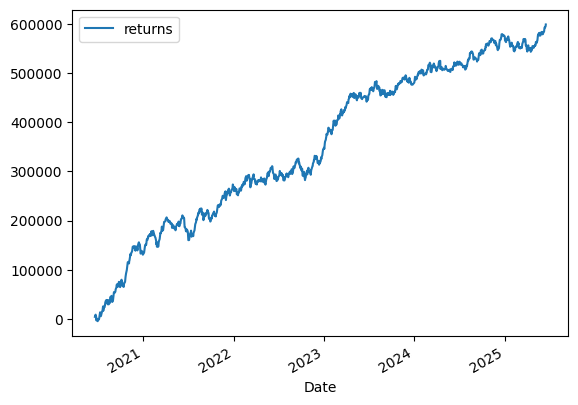

In [173]:
portfolio_ts.data.plot()

<Axes: xlabel='Date'>

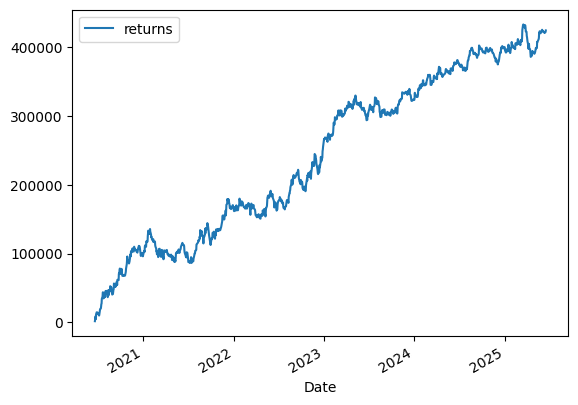

In [81]:
portfolio_ts.data.plot()

<Axes: xlabel='Date'>

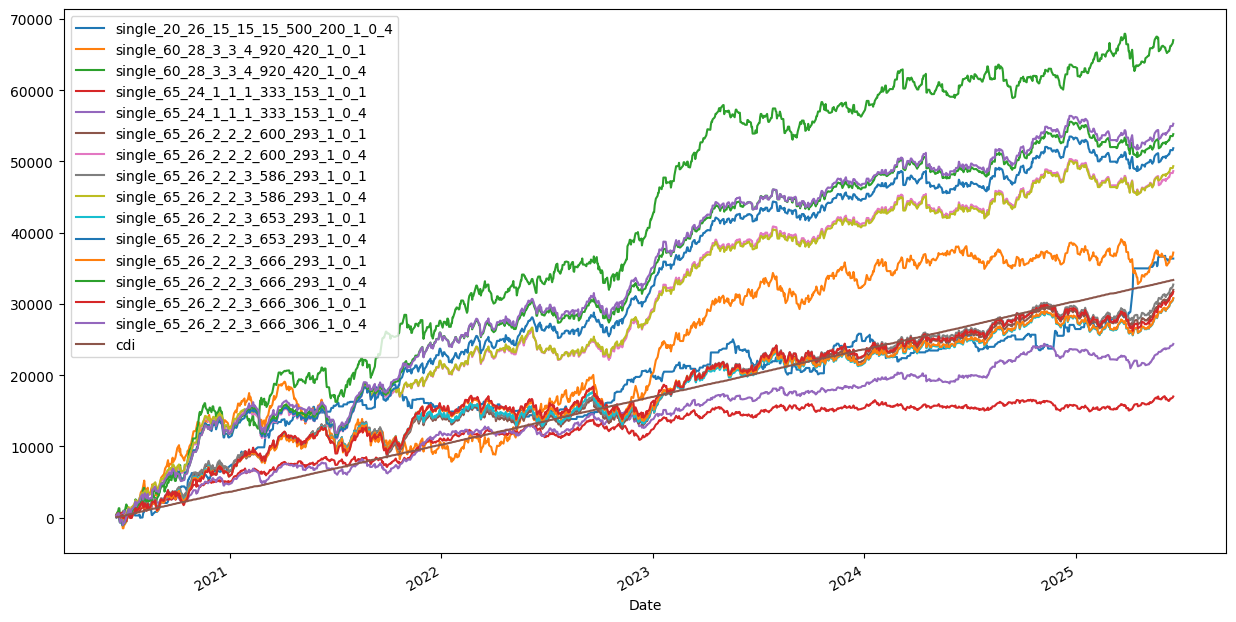

In [174]:
mts.data.plot(figsize=(15, 8))

In [175]:
mts.sharpe_ratio(method='absolute')

single_20_26_15_15_15_500_200_1_0_4    1.499642e+00
single_60_28_3_3_4_920_420_1_0_1       1.064237e+00
single_60_28_3_3_4_920_420_1_0_4       1.707583e+00
single_65_24_1_1_1_333_153_1_0_1       1.323826e+00
single_65_24_1_1_1_333_153_1_0_4       1.676411e+00
single_65_26_2_2_2_600_293_1_0_1       1.321815e+00
single_65_26_2_2_2_600_293_1_0_4       1.797569e+00
single_65_26_2_2_3_586_293_1_0_1       1.359187e+00
single_65_26_2_2_3_586_293_1_0_4       1.828627e+00
single_65_26_2_2_3_653_293_1_0_1       1.244577e+00
single_65_26_2_2_3_653_293_1_0_4       1.922133e+00
single_65_26_2_2_3_666_293_1_0_1       1.242880e+00
single_65_26_2_2_3_666_293_1_0_4       2.013804e+00
single_65_26_2_2_3_666_306_1_0_1       1.258821e+00
single_65_26_2_2_3_666_306_1_0_4       2.038763e+00
cdi                                    7.650476e+14
dtype: float64

In [176]:
mts.max_drawdown(percentage=False)

single_20_26_15_15_15_500_200_1_0_4    -4950.0
single_60_28_3_3_4_920_420_1_0_1      -11225.0
single_60_28_3_3_4_920_420_1_0_4       -5241.0
single_65_24_1_1_1_333_153_1_0_1       -2830.0
single_65_24_1_1_1_333_153_1_0_4       -3431.0
single_65_26_2_2_2_600_293_1_0_1       -4925.0
single_65_26_2_2_2_600_293_1_0_4       -4924.0
single_65_26_2_2_3_586_293_1_0_1       -4785.0
single_65_26_2_2_3_586_293_1_0_4       -4762.0
single_65_26_2_2_3_653_293_1_0_1       -4647.0
single_65_26_2_2_3_653_293_1_0_4       -4848.0
single_65_26_2_2_3_666_293_1_0_1       -4790.0
single_65_26_2_2_3_666_293_1_0_4       -4950.0
single_65_26_2_2_3_666_306_1_0_1       -4608.0
single_65_26_2_2_3_666_306_1_0_4       -4742.0
cdi                                        0.0
dtype: float64

In [177]:
portfolio_ts.max_drawdown(percentage=True)

returns   -12.185158
dtype: float64

In [178]:
portfolio_ts.max_drawdown(percentage=False)

returns   -50410.0
dtype: float64

<Axes: xlabel='Date'>

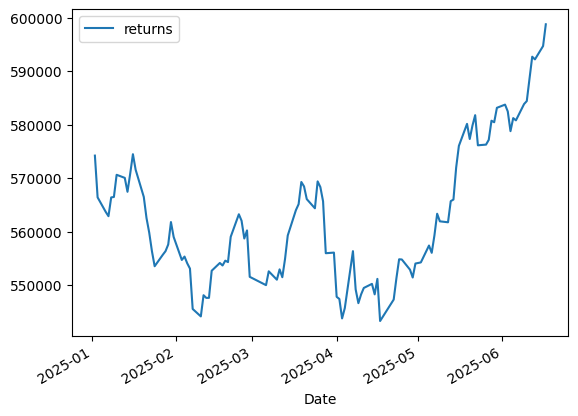

In [179]:
portfolio_ts.data[(portfolio_ts.data.index >= '2025-01-01')].plot()